In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [13]:
!pip install scikit-learn

In [14]:
df = pd.read_csv('../data/q2_customers.csv')
df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


The dataset contains customer behavior data such as spending, visits, and basket size.
Clustering will help group similar customers together.

In [15]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

In [16]:
scaled_data[:5]

array([[-0.72521859, -0.17615043,  0.11016555, -0.26501121, -0.0899507 ,
         0.55095233],
       [-1.48846049, -1.04682639,  0.48615719, -0.9804657 , -0.83517593,
        -0.68068477],
       [ 0.17679458,  0.2673371 , -0.45382191, -0.23685064, -0.67404615,
        -0.27013907],
       [-0.72521859, -1.01230889,  0.29816137, -0.82778261, -0.99630571,
        -1.09123047],
       [-1.48846049, -1.03448783,  1.42613628, -1.00598621, -0.65390493,
        -1.50177617]])

Scaling is important in K-Means because it ensures all features contribute equally.
Without scaling, features with larger values would dominate the clustering process.

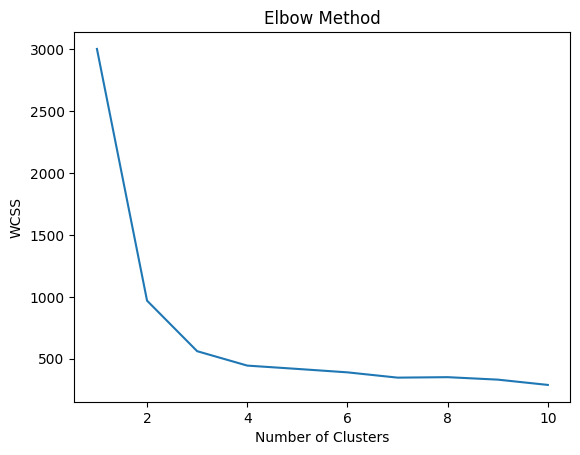

In [17]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

The elbow point appears at K = 3, where the rate of decrease slows down.
Hence, 3 clusters are chosen as optimal.

In [18]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(scaled_data)

df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased,cluster
0,30,43075,9,2080,45,6,2
1,19,14496,11,454,8,3,0
2,43,57632,6,2144,16,4,2
3,30,15629,10,801,0,2,0
4,19,14901,16,396,17,1,0


In [19]:
centroids = pd.DataFrame(kmeans.cluster_centers_, columns=df.columns[:-1])
centroids

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,-1.094595,-1.036122,1.114284,-0.934278,-0.813494,-1.045346
1,1.132214,1.235574,-1.106680,1.253260,1.125725,1.172991
2,-0.004449,-0.168055,-0.041370,-0.290670,-0.287579,-0.095968


Cluster 0: Customers with moderate spending and visits.
Cluster 1: High-value customers with high spending and frequent visits.
Cluster 2: Low engagement customers with low spending and fewer visits.

In [20]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.83560354 0.05568764]


In [21]:
loadings = pd.DataFrame(pca.components_, columns=df.columns[:-1])
loadings

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,0.411569,0.42154,-0.410399,0.412012,0.378582,0.414017
1,-0.259432,-0.03327,0.208318,-0.195402,0.911194,-0.140479


PC1 captures overall spending and engagement behavior.
PC2 captures variation in visit frequency and recency.

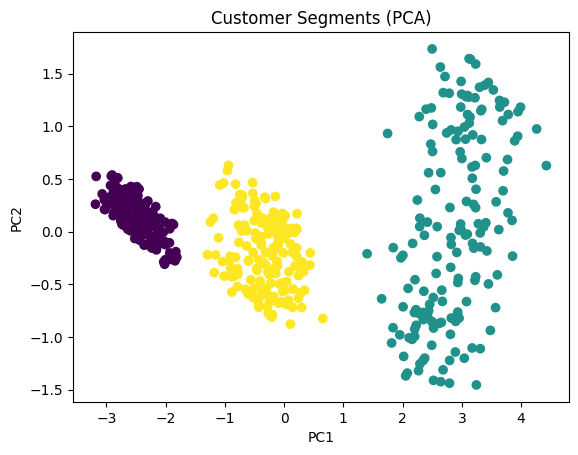

In [22]:
plt.scatter(pca_data[:, 0], pca_data[:, 1], c=df['cluster'])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Customer Segments (PCA)")
plt.show()